In [2]:
# Tutorial https://einops.rocks/1-einops-basics/

import numpy as np


from utils import display_np_arrays_as_images # This is a helper implemented in the local utils module

display_np_arrays_as_images()

In [3]:
ims = np.load("./resources/test_images.npy", allow_pickle=False)
print(ims.shape, ims.dtype)

(6, 96, 96, 3) float64


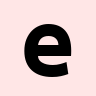

In [3]:
ims[0]

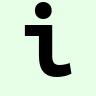

In [5]:
ims[1]

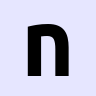

In [6]:
ims[2]

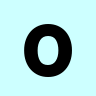

In [7]:
ims[3]

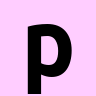

In [8]:
ims[4]

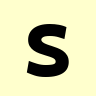

In [9]:
ims[5]

In [4]:
from einops import rearrange, reduce, repeat

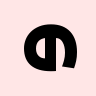

In [ ]:
# We can label each dimension and use -> to specify the output dimensions using the same labels
# swapping the first two dimensions results in transposing the first two axes
# which has the effect of rotating and flipping the image
rearrange(ims[0], "h w c -> w h c")

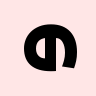

In [8]:
# Labels are arbitrary
rearrange(ims[0], "height width color -> width height color")


## Composition of axes

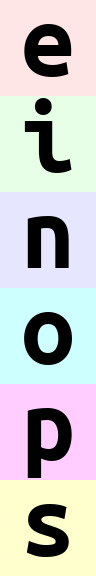

In [16]:
# Collapse the batch and height dimensions into a single dimension, collapsing the 4d tensor to 3d
# Essentially stacking the images into a single image with height b * h
rearrange(ims, "b h w c -> (b h) w c")

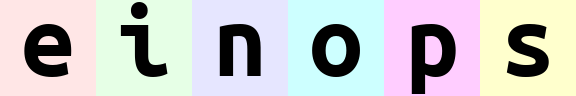

In [18]:
# Now compose batch and width into a new dimension
# Images are stacked horizontally into a single image of width b * w
rearrange(ims, "b h w c -> h (b w) c")

In [ ]:
# Collapse (6, 96, 96 3) to (96, 6 * 96, 3)
rearrange(ims, "b h w c -> h (b w) c").shape

(96, 576, 3)

In [22]:
# We can compose more than 2 axes
# Here we flatten the array
rearrange(ims, "b h w c -> (b h w c)").shape

(165888,)

## Decomposition of axes

In [ ]:
# We can represent as a single dimension on the left hand side as decomposed group of multiple
# components, then use these components to decompose the dimension in the right hand side

# Here we decompose the batch dimension into b1 and b2. einops cannot infer
# the sizes of b1 and b2, so we specify b1=2 and einops infers that b2 = 3.
# This effectively splits a batch of 6 images into 2 batches of 3 images each.

rearrange(ims, "(b1 b2) h w c -> b1 b2 h w c", b1=2).shape

(2, 3, 96, 96, 3)

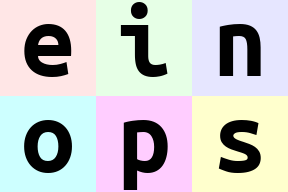

In [25]:
# We can combine composition and decomposition
# Here we split the batch in two, then stack the two batches vertically into a single
# image of height h * b1 and width w * b2

rearrange(ims, "(b1 b2) h w c -> (b1 h) (b2 w) c", b1=2)

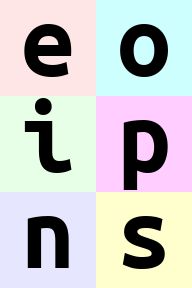

In [27]:
# Here we split the batch in two, each batch is laid out vertically, and the two vertical batches stacked horizontally
# such that we have a single image of height h * b2=3 and w * b1=2

rearrange(ims, "(b1 b2) h w c -> (b2 h) (b1 w) c", b1=2)

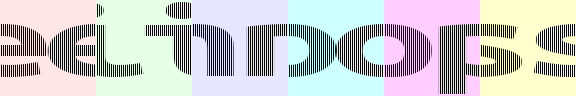

In [76]:
# Split the width image into two and swap the halves
rearrange(ims, "b h (w1 w2) c -> h (b w2 w1) c", w1=2)

In [73]:
# To better understand what's happening, let me try to arrange
# a simple 2D matrix

l = np.array([[1, 2, 3, 4, 5, 6], [11, 12, 13, 14, 15, 16]])

print("Original")
print(l)
print(l.shape)

print()
print("h (w1 w2) -> h w1 w2")
print(rearrange(l, "h (w1 w2) -> h w1 w2", w1=2))

print()
print("(h1 h2) (w1 w2) -> h1 h2 w1 w2")
print(rearrange(l, "(h1 h2) (w1 w2) -> h1 h2 w1 w2", h1=1, w1=2))

print()
print("h (w1 w2) -> h w2 w1")
# w2 w1 is basically a transpose of w1 w2
print(rearrange(l, "h (w1 w2) -> h w2 w1", w1=2))

print()
print("h (w1 w2) -> h (w2 w1)")
# What happens if we transpose without decomposing?
# Equivalent to flattening the transposed version
print(rearrange(l, "h (w1 w2) -> h (w2 w1)", w1=2))

print()
print("h (w1 w2) -> (h w1) w2")
print(rearrange(l, "h (w1 w2) -> (h w1) w2", w1=2))

print()
print("h (w1 w2) -> (h w2) w1")
# I found this to be tricky to understand.
# But a key hint is that w2 w1 is basically a transpose of w1 w2
# So we'll get 1 2 3 laid out vertically across rows instead of horizontally
# Rows will have pairs [1 4], [2 5], [3 6] which are from transposing w1 w2 in the first array h[0]
# Then h[1] will have [11, 14], [12, 15], [13, 16]
# But h and w2 are collapsed into a single dimension, so the two subarrays above are stacked int one
print(rearrange(l, "h (w1 w2) -> (h w2) w1", w1=2))


Original
[[ 1  2  3  4  5  6]
 [11 12 13 14 15 16]]
(2, 6)

h (w1 w2) -> h w1 w2
[[[ 1  2  3]
  [ 4  5  6]]

 [[11 12 13]
  [14 15 16]]]

(h1 h2) (w1 w2) -> h1 h2 w1 w2
[[[[ 1  2  3]
   [ 4  5  6]]

  [[11 12 13]
   [14 15 16]]]]

h (w1 w2) -> h w2 w1
[[[ 1  4]
  [ 2  5]
  [ 3  6]]

 [[11 14]
  [12 15]
  [13 16]]]

h (w1 w2) -> h (w2 w1)
[[ 1  4  2  5  3  6]
 [11 14 12 15 13 16]]

h (w1 w2) -> (h w1) w2
[[ 1  2  3]
 [ 4  5  6]
 [11 12 13]
 [14 15 16]]

h (w1 w2) -> (h w2) w1
[[ 1  4]
 [ 2  5]
 [ 3  6]
 [11 14]
 [12 15]
 [13 16]]


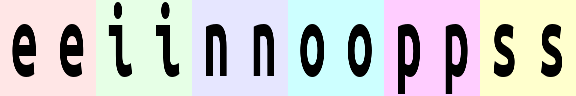

In [93]:
# I did not expect this to print each letter twice in half the width per letter
# We decompose the width in a 48x2 grid, that means
# 42 sub arrays of 2 pixels each. The 2 pixels in each array
# represent adjacent pixels in the image.
# If you take every other pixel of the image along the width, you'll get a similar
# image, but half the width. Adjacent pixels are very likely to have the same color
# in our simple images with only 2 colors, so half the image looks like the original but thinner.
# So when we swap w1 w1 to w2 w1, we get 2x48, 2 arrays where
# the first array gets every even pixel and the second array gets every odd pixel
# and the result is 2 almost-identical halves of the image side by side
# (the "halves" are not exactly the same since they are not the same pixels repeated, but adjacent pixels separated)
# Then we do this for each image in the batch and stack the results horizontally
rearrange(ims, "b h (w1 w2) c -> h (b w2 w1) c", w2=2)

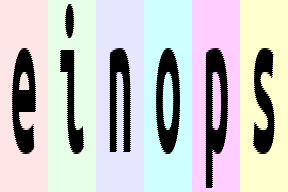

In [ ]:
# move part of width dimension to height.

# Now I can understand the "width-to-height" trick from the docs.
# For each image in the batch, we split the pixels in 2 groups (2x48)
# One with even pixels, the other with odd pixels
# Then instead of placing the groups side-by-side like in the previous example
# We arrange them vertically. So along the new height of each image h*2
# we place alternate over the adjacent pixels, so we get a thin but vertically
# stretched version of the image, then we repeat this across the batches stacked horizontally

# we should call this width-to-height as image width shrunk by 2 and height doubled.
# but all pixels are the same!
rearrange(ims, "b h (w1 w2) c -> (h w2) (b w1) c", w2=2)

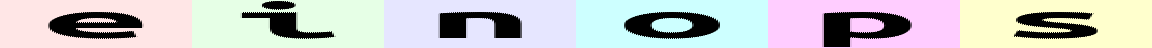

In [113]:
# Now can I try to create the height-to-width effect?
# What would that look like?
# We want to move part of height to width
# Shrink height by 2 and extend width by 2.
# Each image will be wider but shorter.
# We'll take every other pixel along the height axis and insert a column (width axis) that contains these pixels
# h1 h2 = 48 * 2, split height into 48 pairs where each pair has a top pixel and bottom pixel
# We'll remove the "bottom" pixels from below their top counter parts and move them next/to the right of their top counterparts
rearrange(ims, "b (h1 h2) w c -> h1 (b w h2) c", h2=2)

In [ ]:
# To better understand the height-to-width trick
# let's break it down with a simple example
# Let's assume the 2D array represents an image (maybe a grayscale image)
m = np.array([
    [0, 1, 2],
    [10, 11, 12],
    [20, 21, 22],
    [30, 31, 32],
    [40, 41, 42],
    [50, 51, 52],
    [60, 61, 62],
    [70, 71, 72]
])

print()
print("(h1 h2) w -> h1 h2 w")
print(rearrange(m, "(h1 h2) w -> h1 h2 w", h2=2))
# This breaks the height into pairs like
#     [[0 1 2] [10 11 12]]
# and [[20 21 22] [30 31 32]]
# In this case [0 1 2] and [20 21 22] represent arrays of "top pixels"
# and [10 11 12] and [30 31 32] are arrays of "bottom pixels"
# so to move part of height to width, we want to move each
# bottom pixel next to its corresponding top pixel, resulting in:
# [0 10 1 11 2 12] and [20 30 21 31 22 32]

print()
print("(h1 h2) w -> h2 h1 w")
print(rearrange(m, "(h1 h2) w -> h1 (w h2)", h2=2))


(h1 h2) w -> h1 h2 w
[[[ 0  1  2]
  [10 11 12]]

 [[20 21 22]
  [30 31 32]]

 [[40 41 42]
  [50 51 52]]

 [[60 61 62]
  [70 71 72]]]

(h1 h2) w -> h2 h1 w
[[ 0 10  1 11  2 12]
 [20 30 21 31 22 32]
 [40 50 41 51 42 52]
 [60 70 61 71 62 72]]


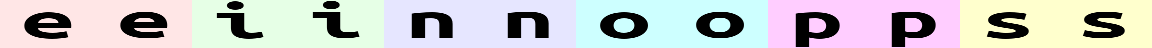

In [114]:
# We can also repeat letters by halving the height if we swap h2 and w
rearrange(ims, "b (h1 h2) w c -> h1 (b h2 w) c", h2=2)

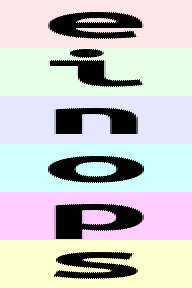

In [116]:
# And by moving b to the height dimension we can arrange them vertically
rearrange(ims, "b (h1 h2) w c -> (b h1) (w h2) c", h2=2)

## Order of axes matter

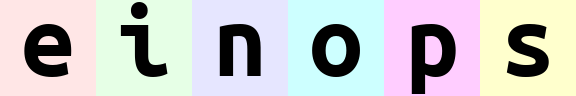

In [120]:
# compare with the next example
rearrange(ims, "b h w c -> h (b w) c")

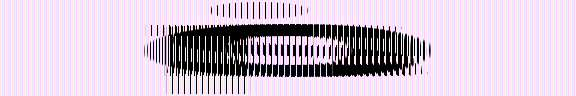

In [121]:
# order of axes in composition is different
# rule is just as for digits in the number: leftmost digit is the most significant,
# while neighboring numbers differ in the rightmost axis.

# you can also think of this as lexicographic sort
rearrange(ims, "b h w c -> h (w b) c")

# So what's happening in this image?
# When we have (b w), we can think of b images of width w each stacked together
# if b*w was a matrix, a single row represents the pixels of a single image along the width
# but in w*b, the first row represents the first pixels of each image, the second row
# contains all the 2nd pixels, etc.
# so in h (w b ) c, the image is the result of stacking the first pixels of all the images
# horizontally, followed by the 2nd pixels, 3rd pixels, etc.

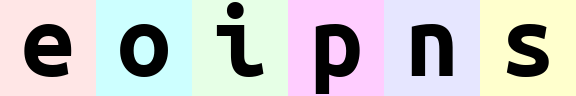

In [123]:
# what if b1 and b2 are reordered before composing to width?
rearrange(ims, "(b1 b2) h w c -> h (b1 b2 w) c ", b1=2)  # produces 'einops'
rearrange(ims, "(b1 b2) h w c -> h (b2 b1 w) c ", b1=2)  # produces 'eoipns'

# Why do we get 'eoipns'?
# we decompose b into (b1 b2), 2*3, 2 rows of 3 images each [e i n] and [o p s]
# (b1 b2) is a rowise arrangement, meaning contenating the rows into [e i n o p s]
# (b2 b1) is a column-wise arrangement, concatenaning [e o] [i p] [n s]

## `einops.reduce`

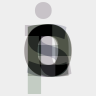

In [124]:
# reduce is used to aggregate data along one or more axes
# you specify the operation name as an argument
# the axes you don't specify in the output pattern are reduced

# Example, average over a batch of images
reduce(ims, "b h w c -> h w c", "mean")

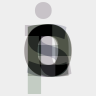

In [125]:
# The previous is equivalent to numpy's
ims.mean(axis=0)

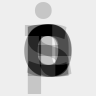

In [132]:
# You can reduce several axes
reduce(ims, "b h w c -> h w", "mean")

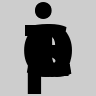

In [135]:
# There are other operations besides mean
reduce(ims, "b h w c -> h w", "min")

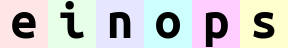

In [139]:
# Mean-pooling with a 2x2 kernel
# image is split into 2x2 patches, each patch is averaged
reduce(ims, "b (h1 h2) (w1 w2) c -> h1 (b w1) c", "mean", h2=2, w2=2)

# Notice we don't have h2 and w2 in the output patterns. The 2x2 pixels are averaged out.
# Leading to half the image size, with nice smoothing due to the averaging

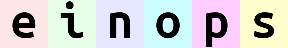

In [140]:
# Max-pooling with a 2x2 kernel
# not as smooth as averaging
reduce(ims, "b (h1 h2) (w1 w2) c -> h1 (b w1) c", "max", h2=2, w2=2)

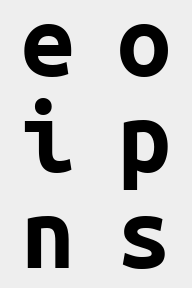

In [ ]:
reduce(ims, "(b1 b2) h w c -> (b2 h) (b1 w)", "mean", b1=2)

In [151]:
reduce(ims, "(b1 b2) h w c -> (b2 h) (b1 w)", "mean", b1=2).shape
# shape is 3*96, 2*96
# color channels are reduced into one per pixel (the mean)

(288, 192)

## Stack and concatenate

In [156]:
# rearrange can also take care of lists of arrays with the same shape
x = list(ims)
print(type(x), "with", len(x), "tensors of shape", x[0].shape)
# that's how we can stack inputs
# "list axis" becomes first ("b" in this case), and we left it there
rearrange(x, "b h w c -> b h w c").shape

<class 'list'> with 6 tensors of shape (96, 96, 3)


(6, 96, 96, 3)

In [157]:
# but new axis can appear in the other place:
rearrange(x, "b h w c -> h w c b").shape

(96, 96, 3, 6)

In [159]:
# that's equivalent to numpy stacking, but written more explicitly
np.array_equal(rearrange(x, "b h w c -> h w c b"), np.stack(x, axis=3))

True

In [160]:
# ... or we can concatenate along axes
rearrange(x, "b h w c -> h (b w) c").shape

(96, 576, 3)

In [161]:
# which is equivalent to concatenation
np.array_equal(rearrange(x, "b h w c -> h (b w) c"), np.concatenate(x, axis=1))

True

## Addition or removal of axes

You can write 1 to create a new axis of length 1. Similarly you can remove such an axis.

There is also a synonym `()` that you can use. That's a composition of zero axes and it also has a unit length.


In [ ]:
x = rearrange(ims, "b h w c -> b 1 h w 1 c") # functionality of np.expand_dims
print(x.shape)
print(rearrange(x, "b 1 h w 1 c -> b h w c").shape) # functionality of np.squeeze

(6, 1, 96, 96, 1, 3)
(6, 96, 96, 3)


In [175]:
print(l)
print(l.shape)
print()
print("h w -> h 1 w")
print(rearrange(l, "h w -> h 1 w"))
print(rearrange(l, "h w -> h 1 w").shape)

print()
print("h w -> 1 h w")
print(rearrange(l, "h w -> 1 h w"))
print(rearrange(l, "h w -> 1 h w").shape)

print()
print("h w -> h w 1")
print(rearrange(l, "h w -> h w 1"))
print(rearrange(l, "h w -> h w 1").shape)


[[ 1  2  3  4  5  6]
 [11 12 13 14 15 16]]
(2, 6)

h w -> h 1 w
[[[ 1  2  3  4  5  6]]

 [[11 12 13 14 15 16]]]
(2, 1, 6)

h w -> 1 h w
[[[ 1  2  3  4  5  6]
  [11 12 13 14 15 16]]]
(1, 2, 6)

h w -> h w 1
[[[ 1]
  [ 2]
  [ 3]
  [ 4]
  [ 5]
  [ 6]]

 [[11]
  [12]
  [13]
  [14]
  [15]
  [16]]]
(2, 6, 1)


In [191]:
print(l)
print(l.shape)

print()
print("h w -> h () w")
# () is a composition of zero axes, has length 1. So synonymous with using 1 in the pattern
print(rearrange(l, "h w -> h () w"))
print(rearrange(l, "h w -> h () w").shape)

print()
print("h w -> h (), max")
print(reduce(l, "h w -> h ()", "max"))
print(reduce(l, "h w -> h ()", "max").shape)
# array of 2 single-element arrays, each with the max of the respective original row

print()
print("h w -> h, max")
print(reduce(l, "h w -> h", "max"))
print(reduce(l, "h w -> h", "max").shape)
# flat array of elements, the max of row

print()
print("h w -> () w", "max")
print(reduce(l, "h w -> () w", "max"))
print(reduce(l, "h w -> () w", "max").shape)

print()
print("h w -> w", "max")
print(reduce(l, "h w -> w", "max"))
print(reduce(l, "h w -> w", "max").shape)

print()
print("h w -> () ()", "max")
print(reduce(l, "h w -> () ()", "max"))
print(reduce(l, "h w -> () ()", "max").shape)
# Array of 1 nested array of length 1 that contains the overall max value in the matrix

print()
print("h w -> ()", "max")
print(reduce(l, "h w -> ()", "max"))
print(reduce(l, "h w -> ()", "max").shape)
# Array of length 1 containing the overall max value in the matrix

print()
print("h w -> ", "max")
print(reduce(l, "h w -> ", "max"))
print(reduce(l, "h w -> ", "max").shape)
# Scalar value, overall max value in the matrix.




[[ 1  2  3  4  5  6]
 [11 12 13 14 15 16]]
(2, 6)

h w -> h () w
[[[ 1  2  3  4  5  6]]

 [[11 12 13 14 15 16]]]
(2, 1, 6)

h w -> h (), max
[[ 6]
 [16]]
(2, 1)

h w -> h, max
[ 6 16]
(2,)

h w -> () w max
[[11 12 13 14 15 16]]
(1, 6)

h w -> w max
[11 12 13 14 15 16]
(6,)

h w -> () () max
[[16]]
(1, 1)

h w -> () max
[16]
(1,)

h w ->  max
16
()


In [ ]:
# Compute max in each image individually
print(reduce(ims, "b h w c -> b () () c", "max"))
print(reduce(ims, "b h w c -> b () () c", "max").shape)
# For each image, computes to the max of each color channel separately and wraps it in nested arrays of the h and w dimensions



[[[[1.         0.90196078 0.90196078]]]


 [[[0.90196078 1.         0.90196078]]]


 [[[0.90196078 0.90196078 1.        ]]]


 [[[0.80392157 1.         1.        ]]]


 [[[1.         0.80392157 1.        ]]]


 [[[1.         1.         0.80392157]]]]
(6, 1, 1, 3)


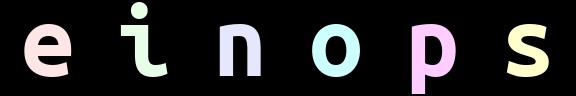

In [200]:
# Compute max in each image individually, then show the difference
x = reduce(ims, "b h w c -> b () () c", "max") - ims
rearrange(x, "b h w c -> h (b w) c")
# In each image, each pixel channel (r, g, b) is substracted from the max value of that channel in that image.
# we're doing a subtraction between shapes (6, 1, 1, 3) and  (6, 96, 96, 3) 
# Note that the tensor of max channels (6, 1, 1, 3) would holds the same amount of data values as (6, 3).
# But adding the extra unit length axes for h and w ensures that both operand tensors of the subtraction
# have the same number of dimensions, this way numpy will broadcast the subtraction properly
# (i.e. each pixel in an image along the height and width is subtracted from the max pixel in that image)
# If dimensions don't match, broadcast will fail



## Repeating elements

In [210]:
# Repeating along a new axis, new axis can be placed anywhere
print(repeat(ims[0], "h w c -> h new_axis w c", new_axis=5).shape)

# Shortcut
print(repeat(ims[0], "h w c -> h 5 w c").shape)

(96, 5, 96, 3)
(96, 5, 96, 3)


In [212]:
print("h w -> h 3 w")
print(repeat(l, "h w -> h 3 w"))
print(repeat(l, "h w -> h 3 w").shape)
# Repeats each row 3 times

print()
print("h w -> 3 h w")
print(repeat(l, "h w -> 3 h w"))
print(repeat(l, "h w -> 3 h w").shape)
# Entire matrix is repeated 3 times

print()
print("h w -> h w 3")
print(repeat(l, "h w -> h w 3"))
print(repeat(l, "h w -> h w 3").shape)
# Each column is repeated 3 times


h w -> h 3 w
[[[ 1  2  3  4  5  6]
  [ 1  2  3  4  5  6]
  [ 1  2  3  4  5  6]]

 [[11 12 13 14 15 16]
  [11 12 13 14 15 16]
  [11 12 13 14 15 16]]]
(2, 3, 6)

h w -> 3 h w
[[[ 1  2  3  4  5  6]
  [11 12 13 14 15 16]]

 [[ 1  2  3  4  5  6]
  [11 12 13 14 15 16]]

 [[ 1  2  3  4  5  6]
  [11 12 13 14 15 16]]]
(3, 2, 6)

h w -> h w 3
[[[ 1  1  1]
  [ 2  2  2]
  [ 3  3  3]
  [ 4  4  4]
  [ 5  5  5]
  [ 6  6  6]]

 [[11 11 11]
  [12 12 12]
  [13 13 13]
  [14 14 14]
  [15 15 15]
  [16 16 16]]]
(2, 6, 3)


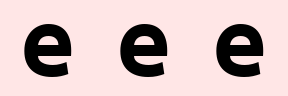

In [213]:
# repeat images along width (existing axis)
repeat(ims[0], "h w c -> h (3 w) c")

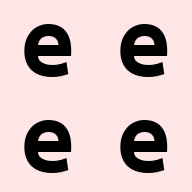

In [215]:
# repeat along 2 existing axes
repeat(ims[0], "h w c -> (2 h) (2 w) c")

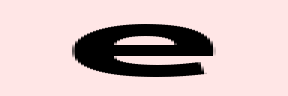

In [219]:
# As usual, order of axes matters. You can repeat each element (pixel) 3 times
# by changing the order in parentheses
repeat(ims[0], "h w c -> h (w 3) c")

## `repeat` and `reduce` are like opposites

In [223]:
# In the following example each image is repeated first,
# then we reduce over new axis to get back original tensor.
# Notice that operation patterns are "reverse" of each other
repeated = repeat(ims, "b h w c -> b h new_axis w c", new_axis=2)
reduced = reduce(repeated, "b h new_axis w c -> b h w c", "min")
assert np.array_equal(ims, reduced)

## Random fancy examples

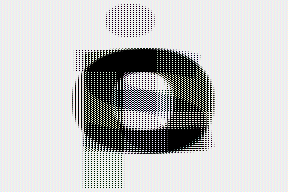

In [224]:
# interweaving pixels of different images
# all letters are observable
rearrange(ims, "(b1 b2) h w c -> (h b1) (w b2) c", b1=2)

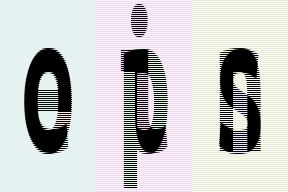

In [226]:
# interweaving along verticals for image pairs
rearrange(ims, "(b1 b2) h w c -> (h b1) (b2 w) c", b1=2)

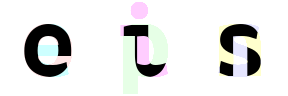

In [227]:
# interweave lines of image pairs
reduce(ims, "(b1 b2) h w c -> h (b2 w) c", "max", b1=2)

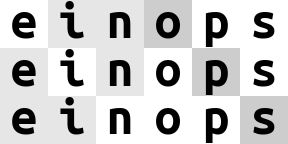

In [228]:
# color can also be composed into a dimension
# ... while image is downsampled
reduce(ims, "b (h 2) (w 2) c -> (c h) (b w)", "mean")

In [229]:
# disproportionate resize
reduce(ims, "b (h 4) (w 3) c -> (h) (b w)", "mean")

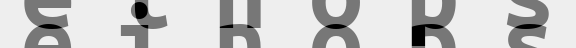

In [230]:
# spilt each image in two halves, compute mean of the two
reduce(ims, "b (h1 h2) w c -> h2 (b w)", "mean", h1=2)

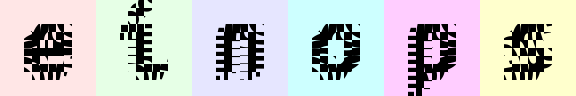

In [231]:

# split in small patches and transpose each patch
rearrange(ims, "b (h1 h2) (w1 w2) c -> (h1 w2) (b w1 h2) c", h2=8, w2=8)

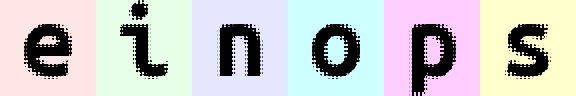

In [232]:
# stop me someone!
rearrange(ims, "b (h1 h2 h3) (w1 w2 w3) c -> (h1 w2 h3) (b w1 h2 w3) c", h2=2, w2=2, w3=2, h3=2)

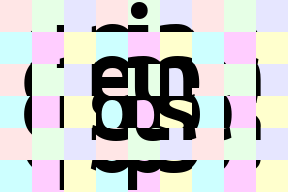

In [234]:
rearrange(ims, "(b1 b2) (h1 h2) (w1 w2) c -> (h1 b1 h2) (w1 b2 w2) c", h1=3, w1=3, b2=3)

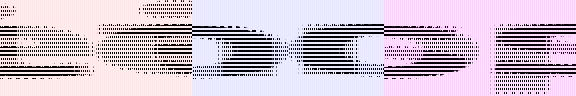

In [235]:
# patterns can be arbitrarily complicated
reduce(ims, "(b1 b2) (h1 h2 h3) (w1 w2 w3) c -> (h1 w1 h3) (b1 w2 h2 w3 b2) c", "mean", h2=2, w1=2, w3=2, h3=2, b2=2)

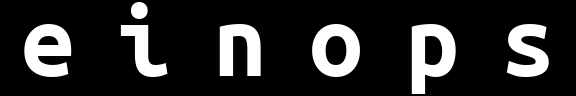

In [236]:
# subtract background in each image individually and normalize
# pay attention to () - this is composition of 0 axis, a dummy axis with 1 element.
im2 = reduce(ims, "b h w c -> b () () c", "max") - ims
im2 /= reduce(im2, "b h w c -> b () () c", "max")
rearrange(im2, "b h w c -> h (b w) c")

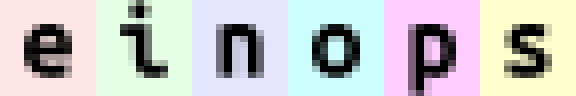

In [237]:
# pixelate: first downscale by averaging, then upscale back using the same pattern
averaged = reduce(ims, "b (h h2) (w w2) c -> b h w c", "mean", h2=6, w2=8)
repeat(averaged, "b h w c -> (h h2) (b w w2) c", h2=6, w2=8)

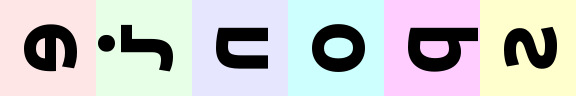

In [238]:
rearrange(ims, "b h w c -> w (b h) c")

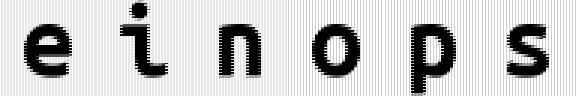

In [239]:
# let's bring color dimension as part of horizontal axis
# at the same time horizontal axis is downsampled by 2x
reduce(ims, "b (h h2) (w w2) c -> (h w2) (b w c)", "mean", h2=3, w2=3)